In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
plt.style.use('grayscale')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#008080',  # #212946
    'axes.facecolor': '#008080',
    'savefig.facecolor': '#008080',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'grid.color': '#000000',  #2A3459
    'grid.linewidth': '1',
    'text.color': '0.9',
    'axes.labelcolor': '0.9',
    'xtick.color': '0.9',
    'ytick.color': '0.9',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18, 7)

In [3]:
from pathlib import Path
import pandas as pd
data_dir = Path("../data/monthly_data.csv")
data = pd.read_csv(data_dir)
data.head()

,month,applied,matched,accepted,approved,realized,completed
0,2022-01-01,8,2,1,0,0,0
1,2022-02-01,11,1,0,0,0,0
2,2022-03-01,52,16,7,3,0,0
3,2022-04-01,89,13,4,2,0,0
4,2022-05-01,132,54,27,20,2,0


In [4]:
'''Prepare dataframe for NiXTLA's Holt-Winters TSA framework
I chose this because it doesn't require large historical data, and there's no clear seasonality
It simply requires only 3 colums: unique_id, ds, y
    unique_id -> unique identifier for series
    ds -> datestamp, which is the month column in our case
    y -> I choose 'approved' since these are confirmed to go on exchange and have less zeros
'''

# Prepare copy of original dataframe
df = data[['month', 'approved']]
df.head()

,month,approved
0,2022-01-01,0
1,2022-02-01,0
2,2022-03-01,3
3,2022-04-01,2
4,2022-05-01,20


In [5]:
df['unique_id'] = "1"
df.columns = ['ds', 'y', 'unique_id']
df.head()

,ds,y,unique_id
0,2022-01-01,0,1
1,2022-02-01,0,1
2,2022-03-01,3,1
3,2022-04-01,2,1
4,2022-05-01,20,1


In [6]:
df['ds'] = pd.to_datetime(df['ds']).dt.to_period("M")
print(df.dtypes)
df.head()

ds           period[M]
y                int64
unique_id          str
dtype: object


,ds,y,unique_id
0,2022-01,0,1
1,2022-02,0,1
2,2022-03,3,1
3,2022-04,2,1
4,2022-05,20,1


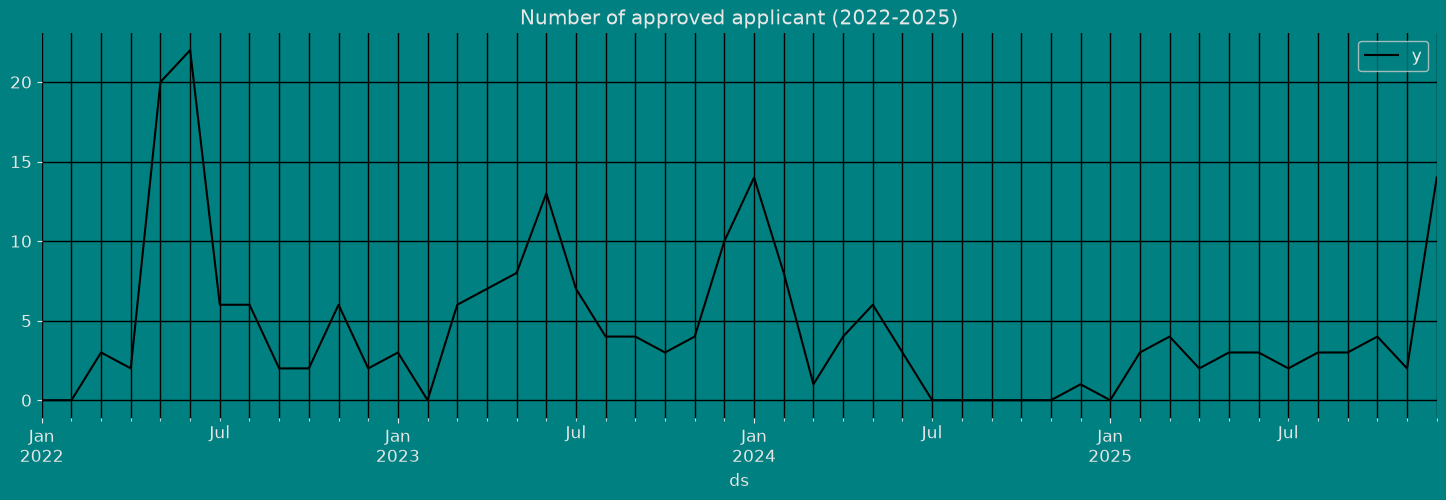

In [7]:
df.plot(x="ds", y="y", figsize=(18, 5))
plt.title("Number of approved applicant (2022-2025)")
plt.show()

In [8]:
# Testing weather time series has a unit root or not
from statsmodels.tsa.stattools import adfuller

def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [9]:
Augmented_Dickey_Fuller_Test_func(df['y'], 'approved')

Dickey-Fuller test results for columns: approved
Test Statistic                 -3.631088
p-value                         0.005194
No Lags Used                    0.000000
Number of observations used    47.000000
Critical Value (1%)            -3.577848
Critical Value (5%)            -2.925338
Critical Value (10%)           -2.600774
dtype: float64
Conclusion:====>
Reject the null hypothesis
The data is stationary


/tmp/ipykernel_276121/3279121453.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(series, autolag='AIC')


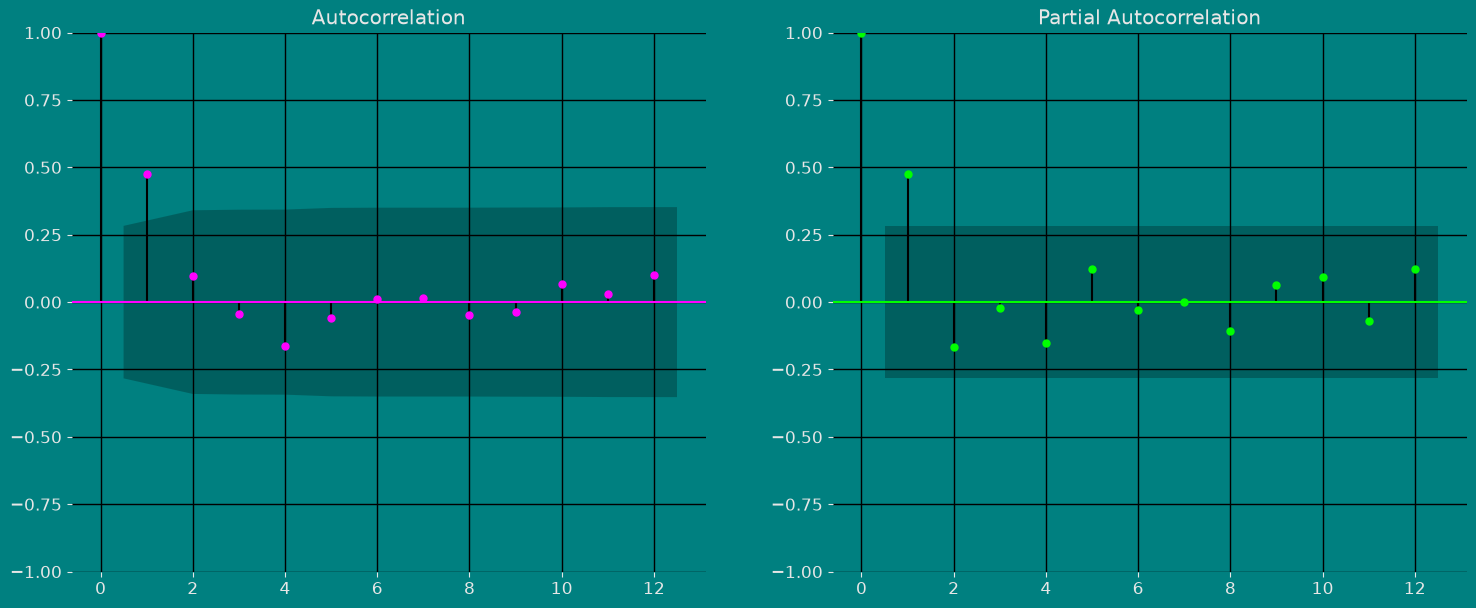

In [10]:
#This is a test for seasonality, with lags =12, I'm simply checking how past data(lag)
#influences data at a given time, 12 represents a 1 year gap
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=12, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=12, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

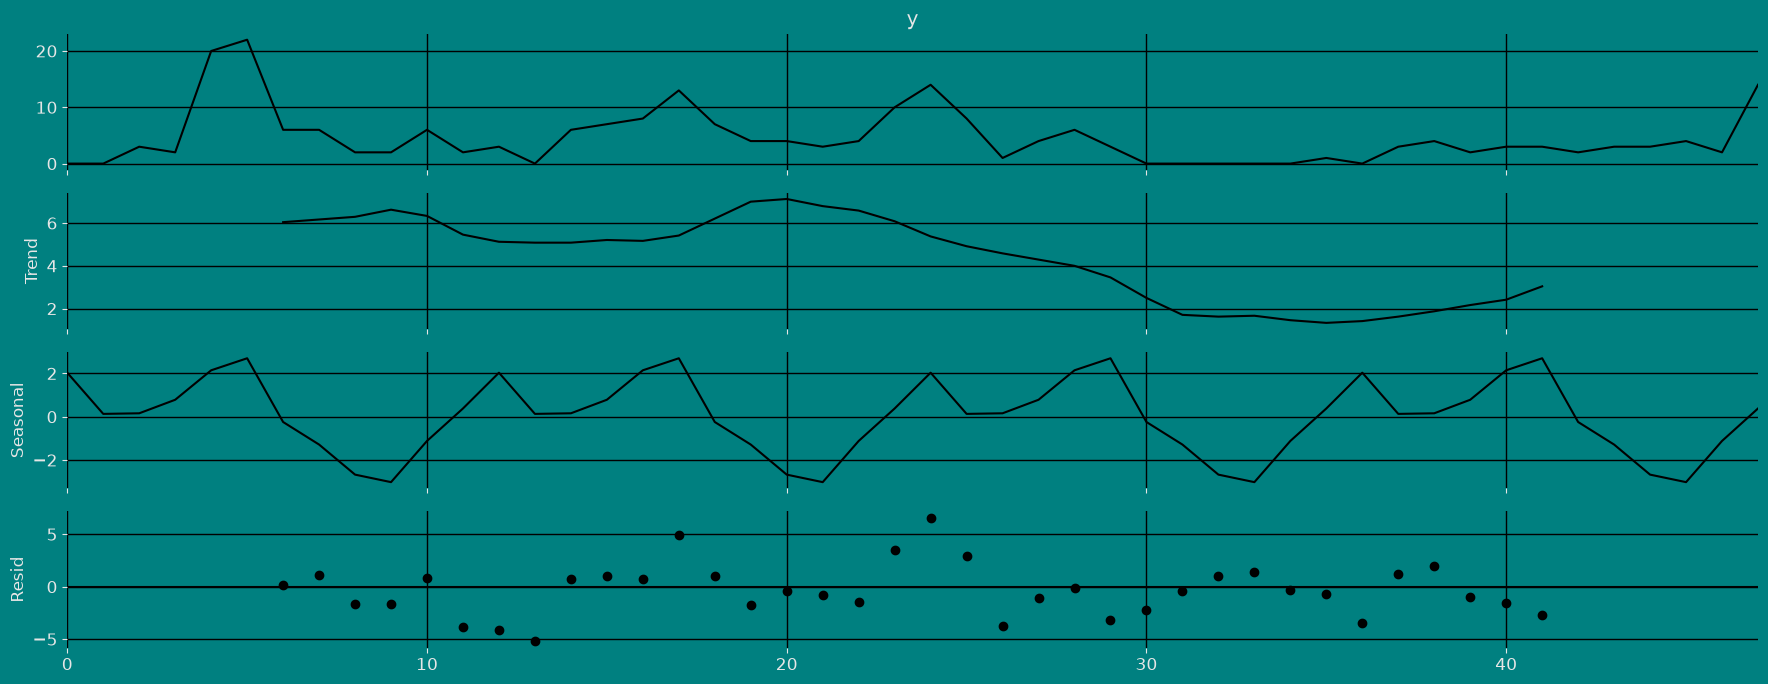

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "additive", period=12)
a.plot();

In [ ]:
#Splitting data
train = df[df.ds <= '2025-01']
test = df[df.ds > '2025-01']

In [15]:
#Saving split data
train.to_csv('train.csv', index= False)
test.to_csv('test.csv', index= False)